In [1]:
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from accelerate import Accelerator
from src.model.data_loader import ScanDataLoader
from src.model.model import AneurysmDetectionModel
from torchsummary import summary
from src.model.training_pipeline import TrainingPipeline, DiceLoss, SegmentationClassificationLoss
from src.model.unet import UNet
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, fbeta_score
import os
import torch.nn.functional as F
import numpy as np
import napari

In [76]:
hyperparams = {
  "batch_size": 1,
  "csv_path": "train.csv",
  "data_dir": "h5-aneurysm",
  "epochs": 10,
  "grad_accum": 2,
  "input_shape": [
    256,
    256,
    256
  ],
  "learning_rate": 0.0001,
  "localizer_csv": "train_localizers.csv",
  "lr_reduction_epochs": 4,
  "max_voxels": 8388608,
  "mode": "local",
  "proportion_to_use": 1,
  "radius": 32,
  "scheduler": {
    "gamma": 0.96,
    "name": "step",
    "step_size": 100
  },
  "train_ratio": 0.7,
  "unet": {
    "activation": "relu",
    "class_output": 1,
    "conv_mode": "same",
    "dropout": 0,
    "in_channels": 1,
    "middle_neurons": 256,
    "n_blocks": 4,
    "normalization": "group4",
    "out_channels": 1,
    "start_filters": 16,
    "up_mode": "transposed",
    "middle_neurons" : 256,
    "class_output": 1,
    "dropout": 0
  },
  "weight_decay": 0.01,
  "weights":[0.999,0.001]
}


In [77]:
def safe_gather(tensor):
        """Safely gather tensors across processes for Gloo backend."""
        tensor = tensor.flatten().contiguous()
        
        # Get max size across processes
        local_size = torch.tensor(tensor.shape[0], device=device)
        all_sizes = accelerator.gather(local_size)
        if not torch.is_tensor(all_sizes):
            all_sizes = torch.tensor([all_sizes], device=device)
        else:
            all_sizes = all_sizes.to(device)
        max_size = all_sizes.max().item() if all_sizes.numel() else 0
        
        # Pad to max size
        current_size = tensor.shape[0]
        if current_size < max_size:
            tensor = torch.nn.functional.pad(tensor, (0, max_size - current_size), value=0)

        gathered = accelerator.gather(tensor)

        if max_size == 0:
            return gathered

        sizes_list = all_sizes.tolist()
        if isinstance(sizes_list, (int, float)):
            sizes_list = [sizes_list]
        masks = [
            (torch.arange(max_size, device=device) < size)
            for size in sizes_list
        ]
        valid_mask = torch.stack(masks, dim=0).flatten()
        return gathered[valid_mask]


In [168]:
np.random.seed(6780)
DATA_DIR = Path("ct_preprocessed/series")
CSV_PATH = Path("ct_preprocessed/train.csv")
LOCALIZER_PATH = Path("ct_preprocessed/train_localizers.csv")
ANEURYSM_PATH = "h5-aneurysm"
device = "cuda"

accelerator = Accelerator(
        mixed_precision = "fp16", 
        gradient_accumulation_steps = 1,
    )

print("\n[1/5] Loading dataset...")
data_loader = ScanDataLoader(
        h5_path=ANEURYSM_PATH,
        csv_path=Path(hyperparams["csv_path"]),
        proportion_to_use=hyperparams["proportion_to_use"] if "proportion_to_use" in hyperparams else 1.0,
        max_voxels=hyperparams.get("max_voxels"),
)
resolved_h5_path = Path(data_loader.h5_path)
x_train, y_train, x_val, y_val = data_loader.split_data(train_ratio=hyperparams["train_ratio"])


print("\n[2/5] Loading model...")
unet_kwargs = dict(hyperparams.get("unet", {}))
model = UNet(**unet_kwargs)
print(type(model))
model.load_state_dict(torch.load("cloud_models/juannico007/Nico_cloud_002/juannico007_Nico_cloud_002.pt", weights_only=True))

if torch.cuda.is_available():
    model = model.to(device)
    print(summary(model, input_size = (1,128,128,128)))


print("\n[3/5] Creating dataloaders...")
pipeline = TrainingPipeline(
        model=model,
        batch_size=hyperparams["batch_size"],
        epochs=1,
        learning_rate=0,
        lr_reduction_patience = 0,
        grad_accum_steps=1,
        localizer_csv = LOCALIZER_PATH,
        radius = hyperparams["radius"],
        weights=hyperparams["weights"]
    )

train_dataloader, val_dataloader = pipeline.create_dataloaders(
    data_loader.h5_path, x_train, y_train, x_val, y_val
)

segmentation_loss = DiceLoss()
classification_loss = nn.BCEWithLogitsLoss()
criterion = DiceLoss()
print("\n[4/5] Evaluating training set...")
eps = 1e-6
train_losses = []
train_dice_scores = []
all_preds, all_labels = [], []
torch.no_grad()
for x_batch, mask_batch, y_batch in tqdm(train_dataloader):
    x_batch = x_batch.to(device, dtype=torch.float16, non_blocking=True)
    mask_batch = mask_batch.to(device, dtype=torch.float16, non_blocking=True)
    y_batch = y_batch.float().unsqueeze(1)
    y_batch = y_batch.to(device, dtype=torch.float16, non_blocking=True)
    with accelerator.accumulate(model):
        with accelerator.autocast():
            outputs = model(x_batch)
        loss = criterion(outputs[0], mask_batch)

    train_losses.append(accelerator.gather(loss.detach()).mean().item())

    #Dice calculation
    with torch.no_grad():
        mask_probs = torch.sigmoid(outputs[0].detach().to(torch.float32))
        targets = mask_batch.detach().to(torch.float32)
        pred_masks = (mask_probs >= 0.5).float()

        pred_sum = pred_masks.sum(dim=(1, 2, 3, 4))
        target_sum = targets.sum(dim=(1, 2, 3, 4))
        intersection = (pred_masks * targets).sum(dim=(1, 2, 3, 4))
        dice = (2.0 * intersection + eps) / (pred_sum + target_sum + eps)
        train_dice_scores.append(dice)

    #Accuracy calculation
    all_preds.append(outputs[1].detach())
    all_labels.append(y_batch.detach())

    if y_batch.int().cpu().numpy()[0] == 1:
        break

#DICE loss stats
train_dice_scores = torch.cat(train_dice_scores, dim=0).to(device, dtype=torch.float32)
train_dice_scores = safe_gather(train_dice_scores)
train_dice_mean = train_dice_scores.cpu().numpy().mean() if train_dice_scores.numel() > 0 else 0.0

#Classification stats
all_preds = torch.cat(all_preds, dim=0).to(device, dtype=torch.float32).contiguous()
all_labels = torch.cat(all_labels, dim=0).to(device, dtype=torch.float32).contiguous()
all_preds  = safe_gather(all_preds)
all_labels = safe_gather(all_labels)

probs = torch.sigmoid(all_preds)
train_preds_np = (probs >= 0.5).int().cpu().numpy().ravel()
train_labels_np  = all_labels.int().cpu().numpy().ravel()

train_acc = accuracy_score(train_labels_np, train_preds_np)
train_f1 = f1_score(train_labels_np, train_preds_np, zero_division=0)
train_f2 = fbeta_score(train_labels_np, train_preds_np, beta=2, zero_division=0)



[1/5] Loading dataset...
[Info] Skipping 1.2.826.0.1.3680043.8.498.10021411248005513321236647460239137906: 10084200 voxels exceed limit (8388608).
[Info] Skipping 1.2.826.0.1.3680043.8.498.10030095840917973694487307992374923817: 12139456 voxels exceed limit (8388608).
[Info] Skipping 1.2.826.0.1.3680043.8.498.10014757658335054766479957992112625961: 21375000 voxels exceed limit (8388608).
[Info] Skipping 1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831: 18713856 voxels exceed limit (8388608).
[Info] Skipping 1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381: 9447840 voxels exceed limit (8388608).
[Info] Skipping 1.2.826.0.1.3680043.8.498.10057981374227560278263065500472865434: 27177512 voxels exceed limit (8388608).
[Info] Skipping 1.2.826.0.1.3680043.8.498.10092666779602341135460882241562348436: 9391536 voxels exceed limit (8388608).
[Info] Skipping 1.2.826.0.1.3680043.8.498.10118104902601294641571465174067732646: 12967716 voxels exceed limit (8388608).


  0%|                                                                 | 0/304 [00:29<?, ?it/s]


In [169]:
print(all_labels)

tensor([1.], device='cuda:0')


In [170]:
outputs[0].shape

torch.Size([1, 1, 192, 208, 208])

In [171]:
mask_batch.shape

torch.Size([1, 1, 192, 208, 208])

/home/nico_quintero/DeepLearning/DL-aneurysm-detection-1/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Text(0.5, 1.0, 'Training Confusion Matrix')

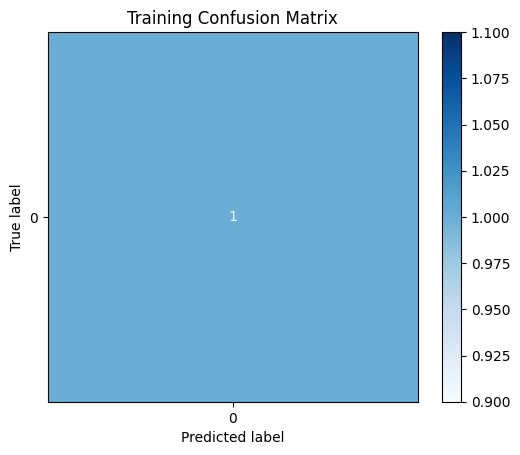

In [172]:
train_conf_mat = confusion_matrix(train_labels_np, train_preds_np)
disp = ConfusionMatrixDisplay(confusion_matrix=train_conf_mat,)
disp.plot(cmap='Blues')  # optional: add color map
plt.title("Training Confusion Matrix")

In [173]:
train_acc

1.0

In [84]:
mask_batch.cpu().detach().numpy().shape, outputs[0].cpu().detach().numpy().shape

((1, 1, 160, 208, 208), (1, 1, 160, 208, 208))

In [85]:
accelerator.backward(loss)

In [174]:
def get_layer_data(model):
  gradients = []
  layer_names = []

  with torch.no_grad():
    for name, param in model.named_parameters():
      if param.requires_grad and name.endswith('.weight') and ("conv" in name or "final" in name or "class" in name):
          layer_names.append(name)
          if param.grad is None:
              gradients.append(torch.tensor(np.zeros((1,1,1,1,1))))
          else:
              gradients.append(param.grad)

  activations = model.activations

  return layer_names, activations, gradients

layer_names, activations, gradients = get_layer_data(model)


In [133]:
print('layer_names',layer_names)
print('Activation list length:',len(activations))
for i, activation in enumerate(activations):
    print(f'Activations shape layer {i}:',activation.shape)

print('Gradient list length:',len(gradients))
for i, gradient in enumerate(gradients):
    print(f'Gradients shape layer {i}:',gradient.shape, type(gradient))

layer_names ['class_block.fc1.weight', 'class_block.fc2.weight', 'final_conv.weight', 'down_blocks.0.conv1.weight', 'down_blocks.0.conv2.weight', 'down_blocks.1.conv1.weight', 'down_blocks.1.conv2.weight', 'down_blocks.2.conv1.weight', 'down_blocks.2.conv2.weight', 'down_blocks.3.conv1.weight', 'down_blocks.3.conv2.weight', 'up_blocks.0.conv1.weight', 'up_blocks.0.conv2.weight', 'up_blocks.0.conv3.weight', 'up_blocks.1.conv1.weight', 'up_blocks.1.conv2.weight', 'up_blocks.1.conv3.weight', 'up_blocks.2.conv1.weight', 'up_blocks.2.conv2.weight', 'up_blocks.2.conv3.weight']
Activation list length: 20
Activations shape layer 0: torch.Size([1, 16, 112, 256, 256])
Activations shape layer 1: torch.Size([1, 16, 112, 256, 256])
Activations shape layer 2: torch.Size([1, 32, 56, 128, 128])
Activations shape layer 3: torch.Size([1, 32, 56, 128, 128])
Activations shape layer 4: torch.Size([1, 64, 28, 64, 64])
Activations shape layer 5: torch.Size([1, 64, 28, 64, 64])
Activations shape layer 6: torc

In [71]:
def get_layer_stats(x,absolute=False):
  avg = []
  std = []
  for layer in range(len(x)):
    if absolute:
      avg.append(x[layer].abs().mean().detach().cpu().numpy())
    else:
      avg.append(x[layer].mean().detach().cpu().numpy())

    std.append(x[layer].std().detach().cpu().numpy())

  return avg, std

activation_mean, activation_std = get_layer_stats(activations)
gradient_mean, gradient_std = get_layer_stats(gradients,absolute=True)

print('activation_mean',activation_mean)
print('activation_std',activation_std)
print('gradient_mean',gradient_mean)
print('gradient_std',gradient_std)

activation_mean [array(0.03262, dtype=float16), array(0.3752, dtype=float16), array(0.487, dtype=float16), array(0.5366, dtype=float16), array(0.3276, dtype=float16), array(0.3938, dtype=float16), array(0.367, dtype=float16), array(0.3372, dtype=float16), array(0.31034243, dtype=float32), array(0.1018694, dtype=float32), array(0.1399, dtype=float16), array(0.6626, dtype=float16), array(0.4553, dtype=float16), array(0.1133, dtype=float16), array(0.7456, dtype=float16), array(0.739, dtype=float16), array(0.1653, dtype=float16), array(1.371, dtype=float16), array(1.061, dtype=float16), array(-7.355, dtype=float16)]
activation_std [array(0.08716, dtype=float16), array(0.64, dtype=float16), array(0.6997, dtype=float16), array(0.903, dtype=float16), array(0.6763, dtype=float16), array(0.991, dtype=float16), array(0.7803, dtype=float16), array(0.985, dtype=float16), array(0.45726383, dtype=float32), array(nan, dtype=float32), array(0.253, dtype=float16), array(1.28, dtype=float16), array(1.33

/tmp/ipykernel_420492/3827933201.py:10: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  std.append(x[layer].std().detach().cpu().numpy())


Gradients:



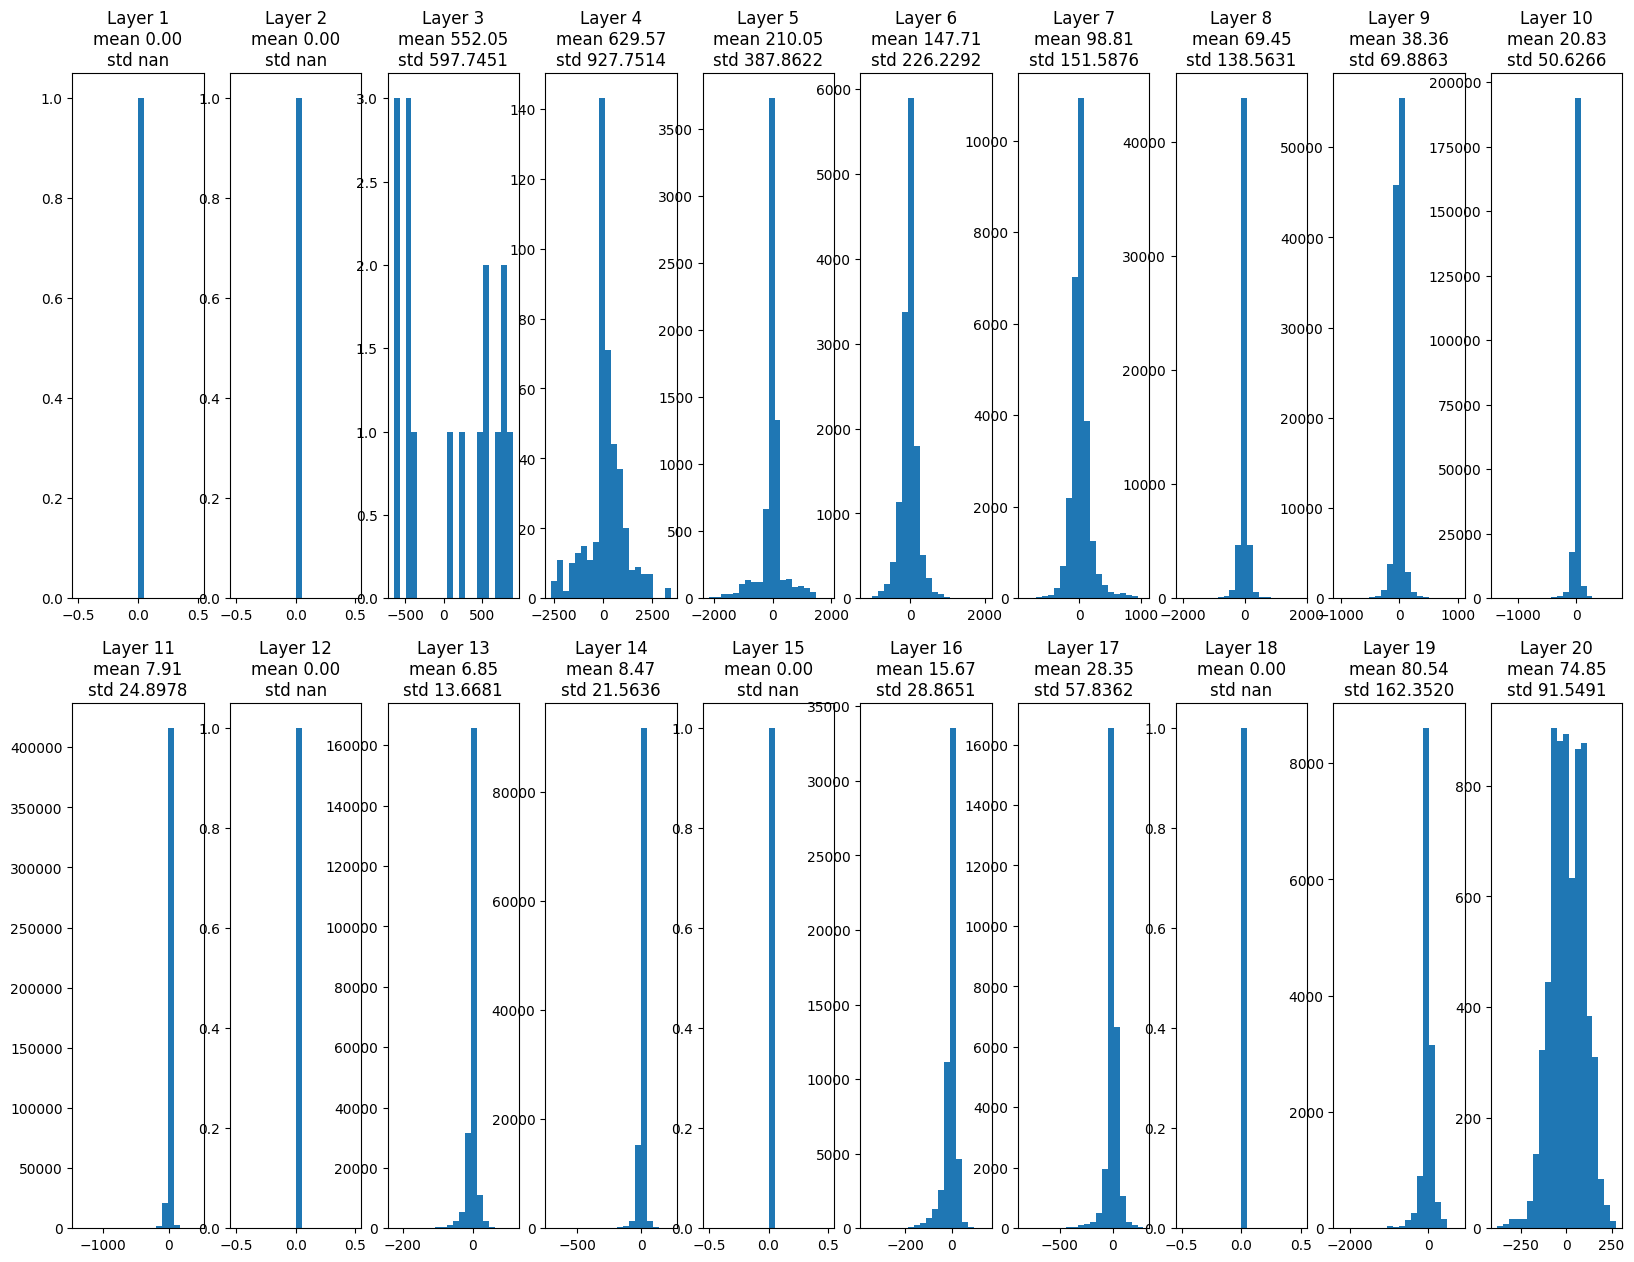

Activations:



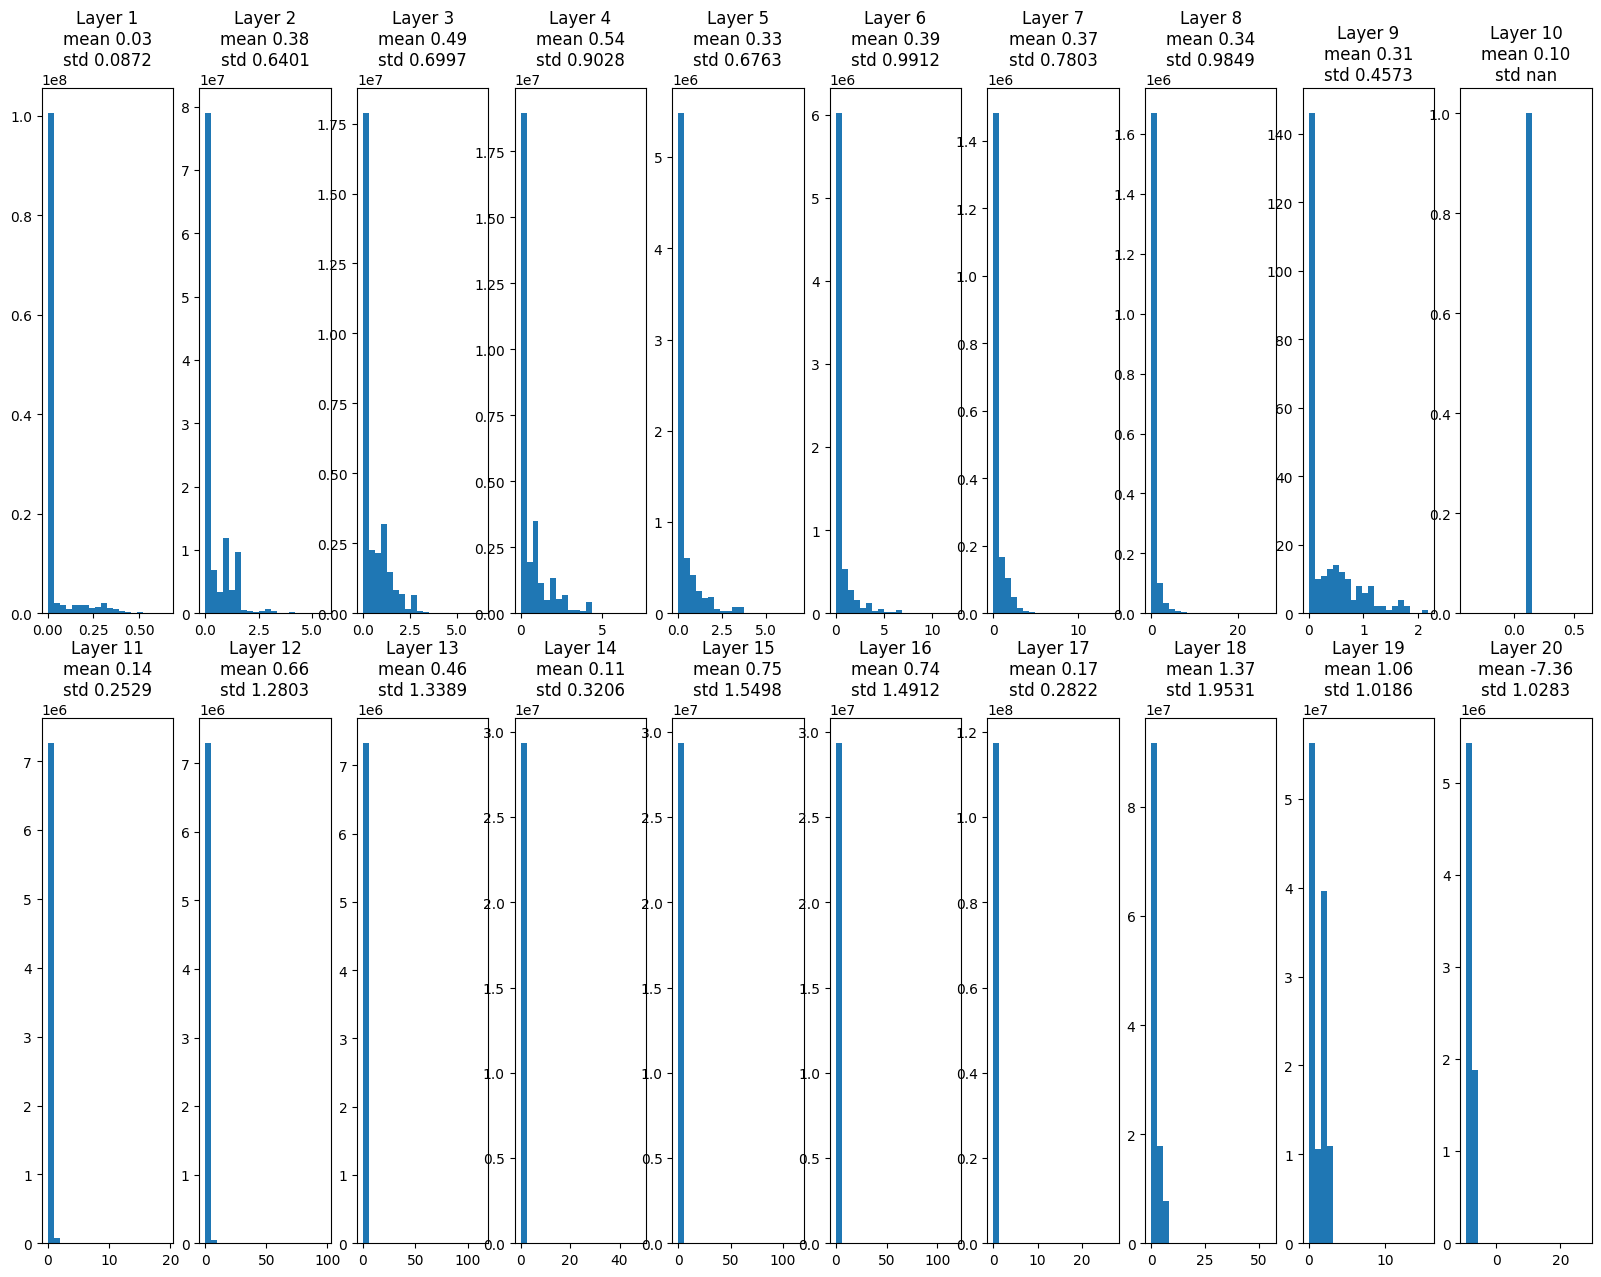

In [72]:
def plot_hist(hs,xrange=(-1,1),avg=None,sd=None):
  plt.figure(figsize=(20,15))
  for layer in range(len(hs)):
    plt.subplot(2,len(hs)//2,layer+1)
    activations = hs[layer].detach().cpu().numpy().flatten()
    plt.hist(activations, bins=20, range=xrange)

    title = 'Layer ' + str(layer+1)
    if avg:
      title += '\n' + "mean {0:.2f}".format(avg[layer])
    if sd:
      title += '\n' + "std {0:.4f}".format(sd[layer])

    plt.title(title)

print('Gradients:\n')
plot_hist(gradients,xrange=None,avg=gradient_mean,sd=gradient_std)
plt.show()

print('Activations:\n')
plot_hist(activations,xrange=None,avg=activation_mean,sd=activation_std)
plt.show()


In [73]:
print(mask_batch.shape)

torch.Size([1, 1, 112, 256, 256])


In [74]:
loss, train_dice_scores

(tensor(0.8959, device='cuda:0', grad_fn=<RsubBackward1>),
 tensor([3.7193e-11, 3.8601e-11, 3.2750e-11, 1.1336e-01], device='cuda:0'))

# X and mask visualization

In [175]:
x_with_mask = np.array([mask_batch.cpu().detach().numpy()[0,0], x_batch.cpu().detach().numpy()[0,0]])
x_with_mask.shape
viewer = napari.Viewer()
viewer.add_image(x_with_mask, channel_axis=0)

viewer

Viewer(camera=Camera(center=(0.0, np.float64(103.5), np.float64(103.5)), zoom=np.float64(2.7403846153846154), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(95.0), 1.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(191.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(207.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(207.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(95.0), np.float64(103.0), np.float64(103.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabl

# Output visualization

In [176]:
import napari
viewer = napari.Viewer()
viewer.add_image(activations[19].cpu().detach().numpy()[0], channel_axis=0)

viewer

Viewer(camera=Camera(center=(0.0, np.float64(103.5), np.float64(103.5)), zoom=np.float64(2.7403846153846154), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(95.0), 1.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(191.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(207.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(207.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(95.0), np.float64(103.0), np.float64(103.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabl

In [179]:
final_map = activations[19].cpu().detach().numpy()[0,0]

In [180]:
final_map.shape

(192, 208, 208)

In [181]:
np.unravel_index(final_map.argmax(), final_map.shape)

(np.int64(89), np.int64(92), np.int64(105))

In [182]:
mask = mask_batch[0,0].cpu().detach().numpy()
mask.shape

(192, 208, 208)

In [183]:
np.unravel_index(mask.argmax(), mask.shape)

(np.int64(74), np.int64(68), np.int64(98))

In [184]:
volume = x_batch[0,0].cpu().detach().numpy()
volume.shape

(192, 208, 208)

In [185]:
def crop_volume(volume, coords, size):
    lower_bounds = [max(coords[0] - size[0]// 2, 0), max(coords[1] - size[1]//2, 0), max(coords[2] - size[2]// 2, 0)]
    
    cropped_volume = volume[lower_bounds[0]:lower_bounds[0]+size[0], lower_bounds[1]:lower_bounds[1]+size[1] , lower_bounds[2]:lower_bounds[2]+size[2]]
    return cropped_volume, lower_bounds

new_vol, cropping_coords = crop_volume(volume, np.unravel_index(mask.argmax(), mask.shape), (64,64,64))
new_mask, _ = crop_volume(mask, np.unravel_index(mask.argmax(), mask.shape), (64,64,64))


In [178]:
cropping_coords

[0, np.int64(77), np.int64(99)]

In [160]:
new_vol.shape

(64, 64, 64)

In [166]:
new_vol_with_mask = np.array([new_mask, new_vol])
viewer = napari.Viewer()
viewer.add_image(new_vol_with_mask, channel_axis=0)

viewer

Viewer(camera=Camera(center=(0.0, np.float64(31.5), np.float64(31.5)), zoom=np.float64(8.90625), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(31.0), 1.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(63.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(63.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(63.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(31.0), np.float64(31.0), np.float64(31.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, spacing=

In [186]:
from skimage.filters import frangi
from skimage import io

frangi_output = frangi(
    volume,
    scale_range=(1, 10),    # adjust depending on vessel size
    scale_step=2,
    alpha=0.5,              # sensitivity to plate-like structures
    beta=0.5,               # sensitivity to blob-like structures
    gamma=15                # noise suppression
)

/tmp/ipykernel_420492/1439425030.py:4: UserWarning: Use keyword parameter `sigmas` instead of `scale_range` and `scale_range` which will be removed in version 0.17.
  frangi_output = frangi(


In [187]:
volume_frangi = np.array([frangi_output, volume])
viewer = napari.Viewer()
viewer.add_image(volume_frangi, channel_axis=0)

viewer

Viewer(camera=Camera(center=(0.0, np.float64(103.5), np.float64(103.5)), zoom=np.float64(2.7403846153846154), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(95.0), 1.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(191.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(207.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(207.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(95.0), np.float64(103.0), np.float64(103.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabl